# ================================================================
# Complete TUAR Artifact Denoising Project Using a Residual GAN
# Paired Data: Noisy input = clean signal + synthetic artifact noise
# The generator learns to predict the artifact residual so that:
#  clean_predicted = noisy_input - predicted_residual
# ================================================================

In [1]:
import os
import numpy as np
import pandas as pd
import mne
from mne import pick_types
from pathlib import Path
from sklearn.model_selection import train_test_split
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
from tqdm import tqdm
import scipy.stats as st
import random

# 1) Imports & Parameters

In [2]:
BASE_DIR = Path("/kaggle/input/eeg-tuar")      # Adjust as needed
EDF_DIR  = BASE_DIR / "edf"
DOCS_DIR = BASE_DIR / "DOCS"
SEG_LEN = 1000               # Length of each segment
EPOCHS = 10
BATCH_SIZE = 32              # For training (use lower batch size for evaluation if desired)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Amplification for clean segments if desired.
CLEAN_AMP_FACTOR = 5.0

# We will use only the first 20 bipolar channels per montage.
FIXED_N_CHANNELS = 20

# 2) TUAR Data Loading

In [4]:
def standardize_channel(ch):
    return ch.replace("EEG ", "").replace("-REF", "").replace("-LE", "").strip().upper()

def load_edf_csv_pair(edf_file):
    """
    Loads an EDF file and its CSV annotation.
    Reads the corresponding montage file as DOCS_DIR / "{mont_name}_montage.txt",
    where mont_name is the parent folder name of the EDF.
    
    IMPORTANT: Only the first 20 montage entries are used.
    """
    edf_path = Path(edf_file)
    # Read EDF using MNE.
    raw = mne.io.read_raw_edf(str(edf_path), preload=True, verbose=False)
    eeg_picks = pick_types(raw.info, eeg=True, meg=False, stim=False)
    raw.pick(picks=eeg_picks)
    sfreq = raw.info["sfreq"]
    
    # Standardize channel names.
    ref_chs = raw.ch_names
    ref_chs_std = [standardize_channel(ch) for ch in ref_chs]
    data_ref = raw.get_data()   # shape: (n_channels, n_times)
    n_times = data_ref.shape[1]
    
    # ------------- Read montage file to build bipolar mapping -------------
    # Use the montage file corresponding to the EDF's parent folder.
    mont_name = edf_path.parent.name  # e.g., "01_tcp_ar" or "04_tcp_le_a", etc.
    mont_file = DOCS_DIR / f"{mont_name}_montage.txt"
    if not mont_file.exists():
        raise FileNotFoundError(f"Montage file {mont_file} not found.")

    bip_map = {}  # Dictionary to hold mapping: label -> (elec1, elec2).
    with open(mont_file, "r") as f:
        for line in f:
            line = line.strip()
            if line.startswith("montage"):
                # Expected form: "montage = <index>, <label>: <electrodes>"
                try:
                    # Split at the comma; the first part contains "montage = <index>"
                    parts = line.split(",")
                    index_part = parts[0].split("=")[1].strip()
                    montage_index = int(index_part)
                except Exception:
                    continue
                # Only use the first 20 montage entries.
                if montage_index >= FIXED_N_CHANNELS:
                    continue
                if len(parts) < 2:
                    continue
                mapping_str = parts[1].strip()
                try:
                    label, electrodes = mapping_str.split(":", 1)
                except ValueError:
                    continue
                label = label.strip()
                electrodes = electrodes.strip()
                # Expected form: "EEG FP1-REF -- EEG F7-REF" (or similar)
                if "--" in electrodes:
                    elec_pair = electrodes.split("--")
                    if len(elec_pair) == 2:
                        elec1 = standardize_channel(elec_pair[0])
                        elec2 = standardize_channel(elec_pair[1])
                        bip_map[label] = (elec1, elec2)
    
    # ------------- Build bipolar signals using montage mapping -------------
    bip_chs = []  # List of bipolar channel labels.
    bip_data = []  # List to store bipolar signals.
    for lab, (elec1, elec2) in bip_map.items():
        if elec1 in ref_chs_std and elec2 in ref_chs_std:
            idx1 = ref_chs_std.index(elec1)
            idx2 = ref_chs_std.index(elec2)
            bip_data.append(data_ref[idx1] - data_ref[idx2])
            bip_chs.append(lab)
    if len(bip_data) == 0:
        raise ValueError(f"No bipolar channels created for EDF: {edf_path}. Check montage mapping.")
    bipolar_data = np.vstack(bip_data)  # shape: (n_bip, n_times)
    
    # ------------- Load CSV annotations to create a mask -------------
    csv_path = edf_path.with_suffix(".csv")
    ann = pd.read_csv(csv_path, comment="#")
    ann["channel_std"] = ann["channel"].apply(lambda x: standardize_channel(str(x)))
    mask = np.zeros(bipolar_data.shape, dtype=bool)  # shape: (n_bip, n_times)
    for _, row in ann.iterrows():
        ch = row["channel_std"]
        if ch in bip_chs:
            idx = bip_chs.index(ch)
            s = int(row.start_time * sfreq)
            e = int(row.stop_time * sfreq)
            s = max(0, min(s, bipolar_data.shape[1]-1))
            e = max(0, min(e, bipolar_data.shape[1]-1))
            mask[idx, s:e] = True
            
    return bipolar_data, ann, bip_chs, mask, sfreq

# 3) Segmenting TUAR Data

Found 310 EDF files.
Setting n_channels = 20
Segmentation complete. Clean windows: 24600, Artifact windows: 22945
Displaying sample pairs of original Clean and Artifact segments (all channels):


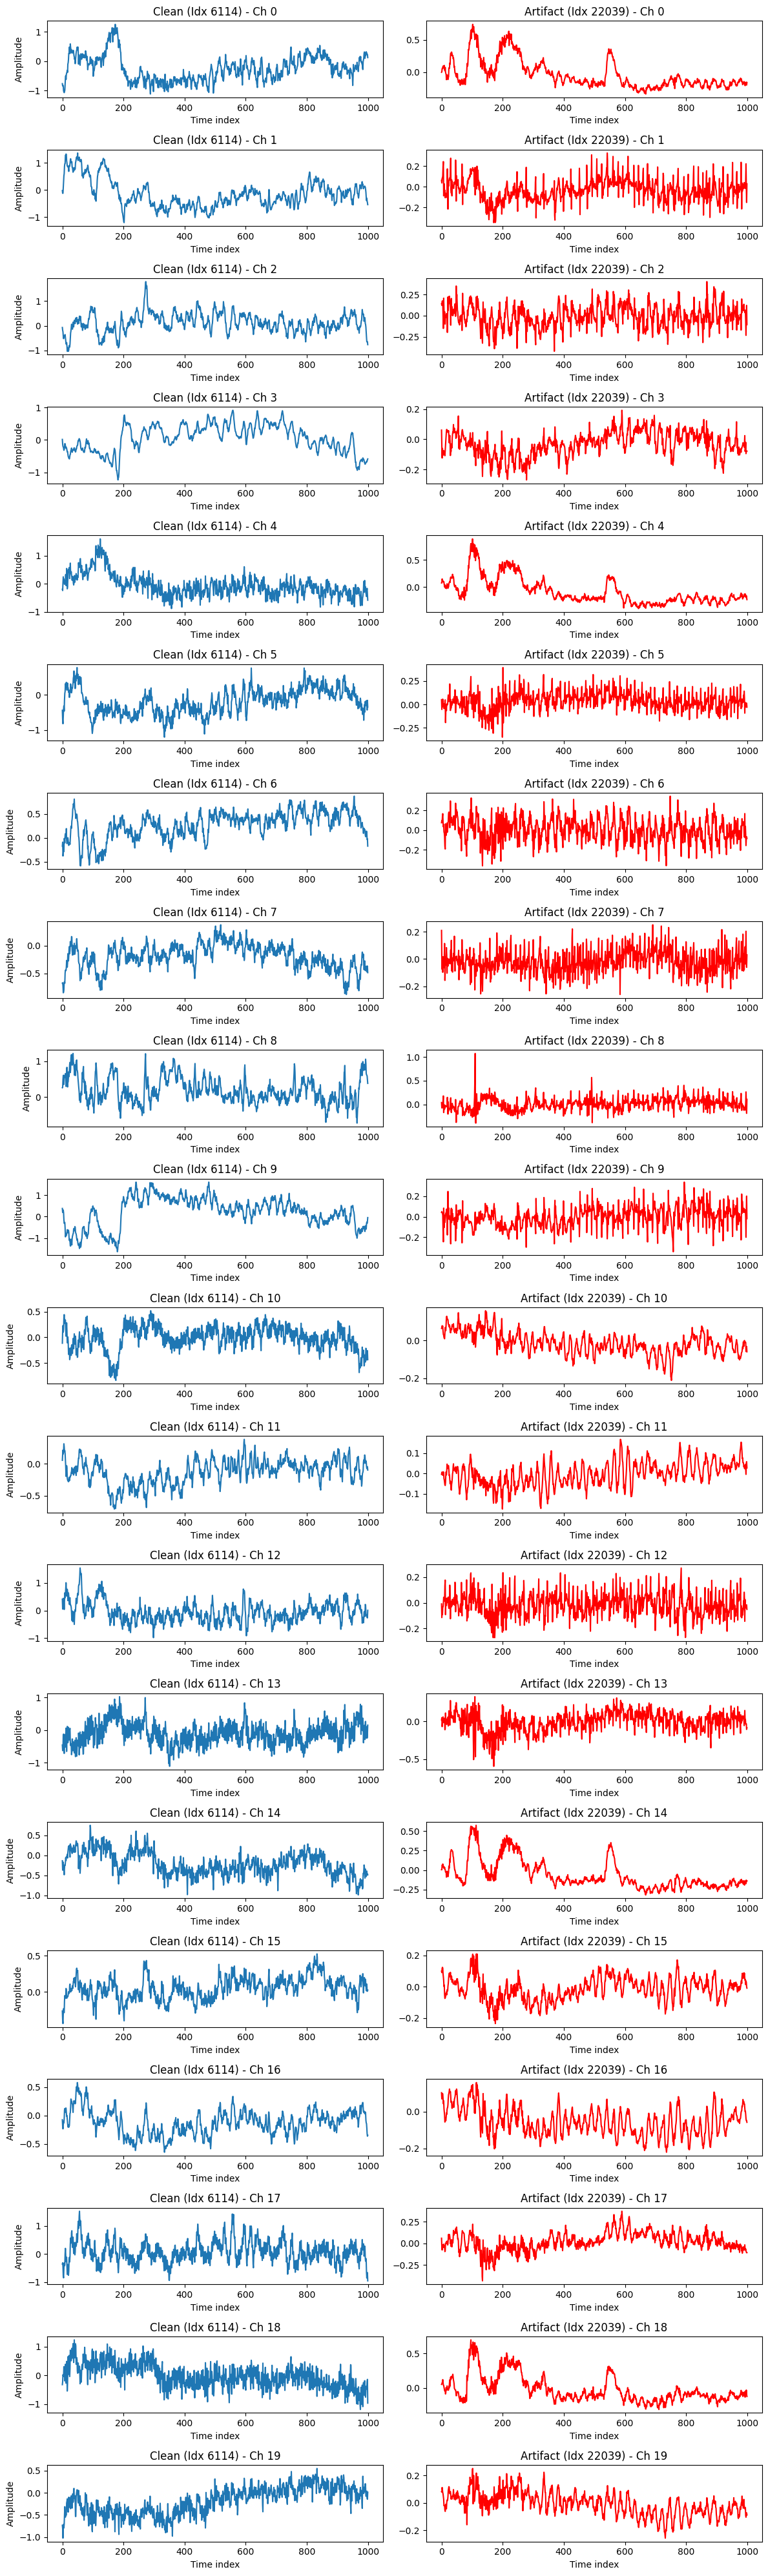

In [5]:
clean_segments = []
artifact_segments = []
n_channels = None  # Will be determined from the first processed EDF.

edf_files = list(EDF_DIR.rglob("*.edf"))
print(f"Found {len(edf_files)} EDF files.")

# Process a subset (for example, the first 150 EDF files)
for edf in edf_files[:150]:
    try:
        bipolar_data, ann, bip_chs, mask, sfreq = load_edf_csv_pair(edf)
    except Exception as e:
        print(f"Skipping {edf} due to error: {e}")
        continue

    # bipolar_data now has shape: (n_bip, n_times).
    if n_channels is None:
        n_channels = bipolar_data.shape[0]  # Expected to be 20.
        print(f"Setting n_channels = {n_channels}")
        if n_channels != FIXED_N_CHANNELS:
            print(f"Warning: Expected {FIXED_N_CHANNELS} channels, but got {n_channels}")
    
    n_times = bipolar_data.shape[1]
    # Scale signals to microvolt-level.
    bipolar_data = bipolar_data * 1e4

    # Extract windows across all channels simultaneously (shape: [n_channels, SEG_LEN]).
    for i in range(0, n_times - SEG_LEN, SEG_LEN):
        window = bipolar_data[:, i:i+SEG_LEN]
        window_mask = mask[:, i:i+SEG_LEN]
        if window_mask.any():
            artifact_segments.append(window)
        else:
            clean_segments.append(window * CLEAN_AMP_FACTOR)

print(f"Segmentation complete. Clean windows: {len(clean_segments)}, Artifact windows: {len(artifact_segments)}")

# --------------- OPTIONAL: Visualize a few raw segments ---------------
num_samples = 1
print("Displaying sample pairs of original Clean and Artifact segments (all channels):")
for i in range(num_samples):
    clean_idx = random.randint(0, len(clean_segments) - 1)
    artifact_idx = random.randint(0, len(artifact_segments) - 1)
    
    clean_seg = clean_segments[clean_idx]       # shape: [n_channels, SEG_LEN]
    artifact_seg = artifact_segments[artifact_idx]  # shape: [n_channels, SEG_LEN]
    
    num_plots = clean_seg.shape[0]
    plt.figure(figsize=(12, num_plots*2))
    for ch in range(num_plots):
        plt.subplot(num_plots, 2, 2*ch+1)
        plt.plot(clean_seg[ch])
        plt.title(f"Clean (Idx {clean_idx}) - Ch {ch}")
        plt.xlabel("Time index")
        plt.ylabel("Amplitude")
        plt.subplot(num_plots, 2, 2*ch+2)
        plt.plot(artifact_seg[ch], color='red')
        plt.title(f"Artifact (Idx {artifact_idx}) - Ch {ch}")
        plt.xlabel("Time index")
    plt.tight_layout()
    plt.show()

# 4) Create Paired Data for Supervised Learning (Optional)

In [6]:
# Assume your pairing function (using fixed clean) is defined as:
def create_paired_artifact_from_original(clean_segs, artifact_segs, scale_artifact=False, target_ratio=0.3, num_pairs=None):
    """
    Creates paired noisy samples using a fixed clean segment (clean_segs[0])
    for all pairs, and a randomly selected artifact segment.
    
    Returns:
        paired_artifacts (list): List of noisy samples (fixed_clean + artifact).
        paired_cleans (list): List of the fixed clean segment repeated.
    """
    if num_pairs is None:
        num_pairs = len(artifact_segs)
    
    paired_artifacts = []
    paired_cleans = []
    fixed_clean = clean_segs[0]  # use the same clean segment for all pairs
    n_artifacts = len(artifact_segs)
    eps = 1e-10
    for _ in range(num_pairs):
        art_idx = np.random.randint(0, n_artifacts)
        art_seg = artifact_segs[art_idx]
        
        if scale_artifact:
            max_clean = np.max(np.abs(fixed_clean))
            max_art = np.max(np.abs(art_seg))
            scale = (target_ratio * max_clean) / (max_art + eps)
            art_scaled = art_seg * scale
        else:
            art_scaled = art_seg
        
        paired_artifacts.append(fixed_clean + art_scaled)
        paired_cleans.append(fixed_clean)
    
    return paired_artifacts, paired_cleans

# Generate the paired data using fixed clean segment.
paired_artifact_segments, paired_clean_segments = create_paired_artifact_from_original(
    clean_segments, artifact_segments, scale_artifact=False)

# 5) Dataset & DataLoader

In [7]:
class EEGDataset(Dataset):
    def __init__(self, clean_segs, artifact_segs):
        assert len(clean_segs) == len(artifact_segs), "Paired data must have equal lengths."
        self.clean = clean_segs
        self.artifact = artifact_segs

    def __len__(self):
        return len(self.clean)

    def __getitem__(self, idx):
        clean_tensor = torch.tensor(self.clean[idx]).float()    # shape: [n_channels, SEG_LEN]
        artifact_tensor = torch.tensor(self.artifact[idx]).float()
        return artifact_tensor, clean_tensor  # (noisy input, clean target)

train_clean, test_clean, train_artifact, test_artifact = train_test_split(
    paired_clean_segments, paired_artifact_segments, test_size=0.2, random_state=42
)

train_dataset = EEGDataset(train_clean, train_artifact)
test_dataset  = EEGDataset(test_clean, test_artifact)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader  = DataLoader(test_dataset, batch_size=1, shuffle=False)

In [8]:
# Print a few clean-artifact pairs from test_loader (first 3 channels only)
num_samples_to_print = 3  # Adjust how many pairs you want to print

print("=== Sample Clean and Artifact Signal Pairs (First 3 Channels) ===")
for idx, (artifact_input, clean_input) in enumerate(test_loader):
    # artifact_input and clean_input are of shape [batch, n_channels, SEG_LEN].
    # Since batch_size=1, we extract the first sample (index 0) and then the first 3 channels.
    artifact_np = artifact_input.cpu().numpy()[0, :3, :]  # shape: [3, SEG_LEN]
    clean_np    = clean_input.cpu().numpy()[0, :3, :]     # shape: [3, SEG_LEN]

    print(f"Sample {idx+1}:")
    for ch in range(artifact_np.shape[0]):
        print(f" Channel {ch+1}:")
        print("  Artifact Signal (first 10 values):", artifact_np[ch, :10])
        print("  Clean Signal    (first 10 values):", clean_np[ch, :10])
    print("------------------------------------------------------")
    
    if idx + 1 >= num_samples_to_print:
        break

=== Sample Clean and Artifact Signal Pairs (First 3 Channels) ===
Sample 1:
 Channel 1:
  Artifact Signal (first 10 values): [ 0.89828414  0.87671864  0.74007845  0.5761135   0.7867406   0.778375
  0.38891006 -0.07231375  0.46679807  0.79603106]
  Clean Signal    (first 10 values): [0.4498903  0.40490127 0.26993418 0.26993418 0.3149232  0.3149232
 0.22494514 0.08997805 0.         0.08997805]
 Channel 2:
  Artifact Signal (first 10 values): [ 0.8676132   0.6242638   0.5960059   0.65326166  0.42720664  0.313805
  0.42813152  1.1035136   0.1420295  -0.15652424]
  Clean Signal    (first 10 values): [0.58485734 0.35991222 0.3149232  0.22494514 0.26993418 0.17995611
 0.04498903 0.17995611 0.04498903 0.22494514]
 Channel 3:
  Artifact Signal (first 10 values): [0.71256876 0.56737804 0.5591975  0.49710736 0.31696627 0.08626188
 0.85664135 1.014292   1.085681   0.7506804 ]
  Clean Signal    (first 10 values): [0.4498903  0.35991222 0.3149232  0.35991222 0.22494514 0.17995611
 0.40490127 0.71982

# 6) Model Definitions

In [9]:
# Generator: Processes multi-channel input of shape [batch, n_channels, SEG_LEN].
class ResidualGenerator(nn.Module):
    def __init__(self, n_channels):
        super(ResidualGenerator, self).__init__()
        self.lstm = nn.LSTM(input_size=n_channels, hidden_size=50, num_layers=2, batch_first=True)
        self.fc   = nn.Linear(50, n_channels)
    
    def forward(self, x):
        # x: (batch, n_channels, SEG_LEN) --> Permute to (batch, SEG_LEN, n_channels)
        x = x.permute(0, 2, 1)
        lstm_out, _ = self.lstm(x)  # (batch, SEG_LEN, 50)
        residual = torch.tanh(self.fc(lstm_out))  # (batch, SEG_LEN, n_channels)
        residual = residual.permute(0, 2, 1)  # -> (batch, n_channels, SEG_LEN)
        return residual

def calc_final_length_exact(seq_len):
    L = seq_len
    for i in range(4):
        L_conv = ((L - 1) // 2) + 1
        L = L_conv // 2
    return L

final_len = calc_final_length_exact(SEG_LEN)

# Discriminator: Modified to accept multi-channel input.
class Discriminator(nn.Module):
    def __init__(self, n_channels, seg_len):
        super(Discriminator, self).__init__()
        def block(in_channels, out_channels):
            return nn.Sequential(
                nn.Conv1d(in_channels, out_channels, kernel_size=7, stride=2, padding=3),
                nn.LeakyReLU(0.2),
                nn.MaxPool1d(2)
            )
        self.net = nn.Sequential(
            block(n_channels, 16),
            block(16, 32),
            block(32, 64),
            block(64, 64),
            nn.Flatten(),
            nn.Linear(64 * calc_final_length_exact(seg_len), 1)
        )
    def forward(self, x):
        return self.net(x)

# Instantiate models.
G = ResidualGenerator(n_channels).to(device)
D = Discriminator(n_channels, SEG_LEN).to(device)
optG = optim.Adam(G.parameters(), lr=5e-4)
optD = optim.Adam(D.parameters(), lr=5e-5)
mse_loss = nn.MSELoss()
bce_loss = nn.BCEWithLogitsLoss()
lam = 0.01

# 7) Training Loop (Residual Learning)

Epoch 1: 100%|██████████| 574/574 [00:15<00:00, 36.82it/s]


Epoch 1: D-loss = 1.1705, G-loss = 1.9362
Epoch 1: Avg SNR = 6.46 dB, Avg RRMSE = 0.9331, Avg Corr = 0.8429
Paired t-test: t-stat = 8.5832, p-value = 9.2306e-18
✅ Best model updated (lower G-loss)! Saved at /kaggle/working/checkpoint_epoch_best.pth


/tmp/ipykernel_31/417704981.py:160: UserWarning: Tight layout not applied. tight_layout cannot make axes height small enough to accommodate all axes decorations.
  plt.tight_layout(rect=[0, 0, 1, 0.95])


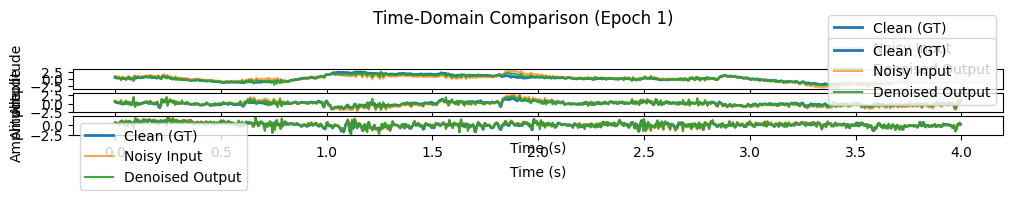

Epoch 2: 100%|██████████| 574/574 [00:13<00:00, 41.02it/s]


Epoch 2: D-loss = 0.8287, G-loss = 1.8584
Epoch 2: Avg SNR = 7.24 dB, Avg RRMSE = 0.8847, Avg Corr = 0.8561
Paired t-test: t-stat = 53.2676, p-value = 0.0000e+00
✅ Best model updated (lower G-loss)! Saved at /kaggle/working/checkpoint_epoch_best.pth


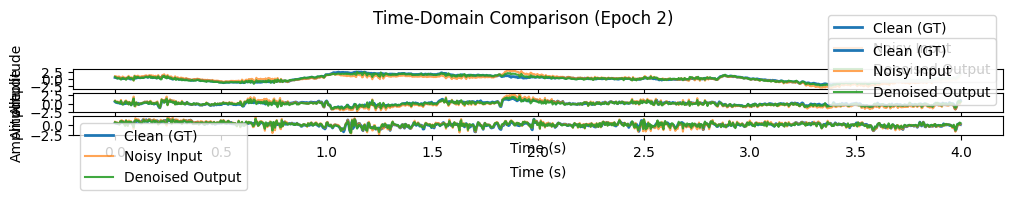

Epoch 3: 100%|██████████| 574/574 [00:13<00:00, 41.04it/s]


Epoch 3: D-loss = 0.7458, G-loss = 1.8357
Epoch 3: Avg SNR = 7.54 dB, Avg RRMSE = 0.8654, Avg Corr = 0.8622
Paired t-test: t-stat = 6.4676, p-value = 9.9592e-11
✅ Best model updated (lower G-loss)! Saved at /kaggle/working/checkpoint_epoch_best.pth


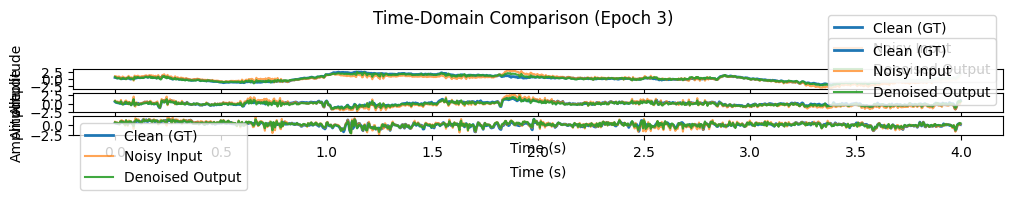

Epoch 4: 100%|██████████| 574/574 [00:13<00:00, 41.12it/s]


Epoch 4: D-loss = 0.7465, G-loss = 1.8299
Epoch 4: Avg SNR = 7.83 dB, Avg RRMSE = 0.8501, Avg Corr = 0.8673
Paired t-test: t-stat = 12.0112, p-value = 3.1022e-33
✅ Best model updated (lower G-loss)! Saved at /kaggle/working/checkpoint_epoch_best.pth


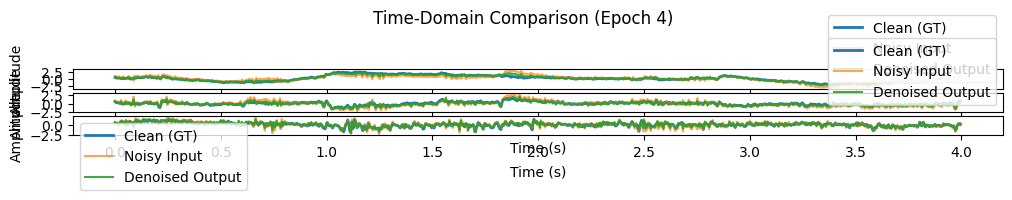

Epoch 5: 100%|██████████| 574/574 [00:13<00:00, 41.14it/s]


Epoch 5: D-loss = 0.7360, G-loss = 1.8194
Epoch 5: Avg SNR = 7.97 dB, Avg RRMSE = 0.8439, Avg Corr = 0.8699
Paired t-test: t-stat = 58.2114, p-value = 0.0000e+00
✅ Best model updated (lower G-loss)! Saved at /kaggle/working/checkpoint_epoch_best.pth


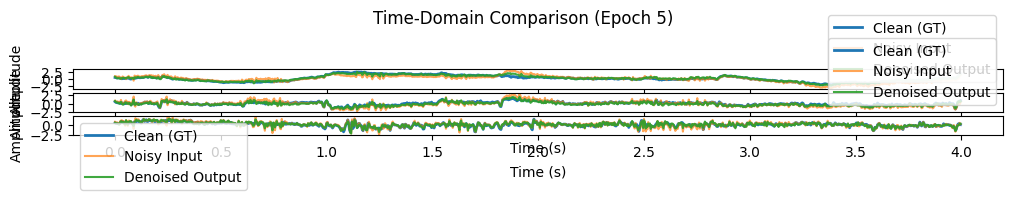

Epoch 6: 100%|██████████| 574/574 [00:14<00:00, 40.96it/s]


Epoch 6: D-loss = 0.7323, G-loss = 1.8170
Epoch 6: Avg SNR = 7.93 dB, Avg RRMSE = 0.8427, Avg Corr = 0.8696
Paired t-test: t-stat = 52.0784, p-value = 0.0000e+00
✅ Best model updated (lower G-loss)! Saved at /kaggle/working/checkpoint_epoch_best.pth


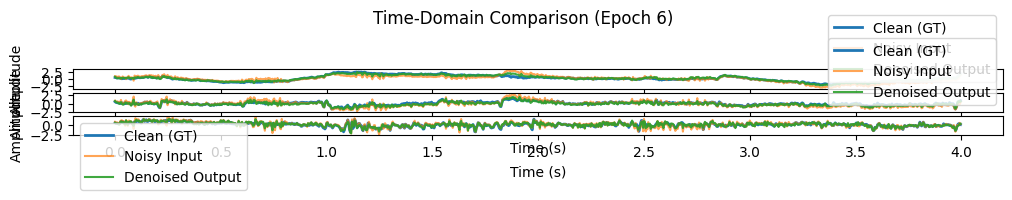

Epoch 7: 100%|██████████| 574/574 [00:13<00:00, 42.19it/s]


Epoch 7: D-loss = 0.7354, G-loss = 1.8143
Epoch 7: Avg SNR = 7.99 dB, Avg RRMSE = 0.8398, Avg Corr = 0.8712
Paired t-test: t-stat = 63.9093, p-value = 0.0000e+00
✅ Best model updated (lower G-loss)! Saved at /kaggle/working/checkpoint_epoch_best.pth


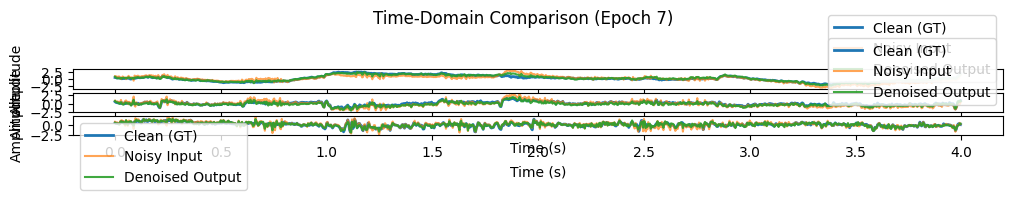

Epoch 8: 100%|██████████| 574/574 [00:13<00:00, 42.28it/s]


Epoch 8: D-loss = 0.7148, G-loss = 1.8130
Epoch 8: Avg SNR = 8.18 dB, Avg RRMSE = 0.8329, Avg Corr = 0.8729
Paired t-test: t-stat = 72.6706, p-value = 0.0000e+00
✅ Best model updated (lower G-loss)! Saved at /kaggle/working/checkpoint_epoch_best.pth


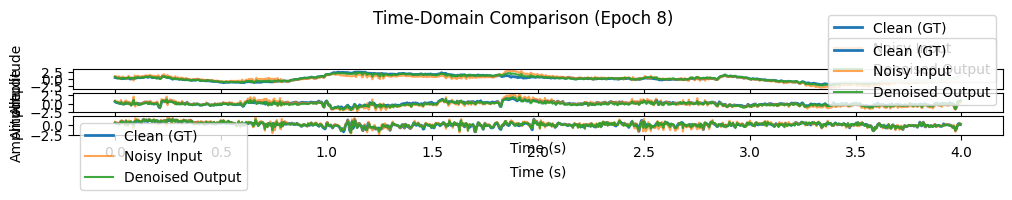

Epoch 9: 100%|██████████| 574/574 [00:13<00:00, 42.28it/s]


Epoch 9: D-loss = 0.7084, G-loss = 1.8117
Epoch 9: Avg SNR = 8.21 dB, Avg RRMSE = 0.8312, Avg Corr = 0.8741
Paired t-test: t-stat = 77.8395, p-value = 0.0000e+00
✅ Best model updated (lower G-loss)! Saved at /kaggle/working/checkpoint_epoch_best.pth


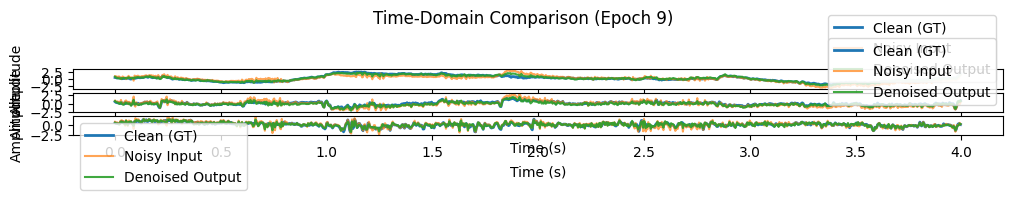

Epoch 10: 100%|██████████| 574/574 [00:13<00:00, 42.79it/s]


Epoch 10: D-loss = 0.7170, G-loss = 1.8102
Epoch 10: Avg SNR = 8.25 dB, Avg RRMSE = 0.8293, Avg Corr = 0.8742
Paired t-test: t-stat = 67.2595, p-value = 0.0000e+00
✅ Best model updated (lower G-loss)! Saved at /kaggle/working/checkpoint_epoch_best.pth


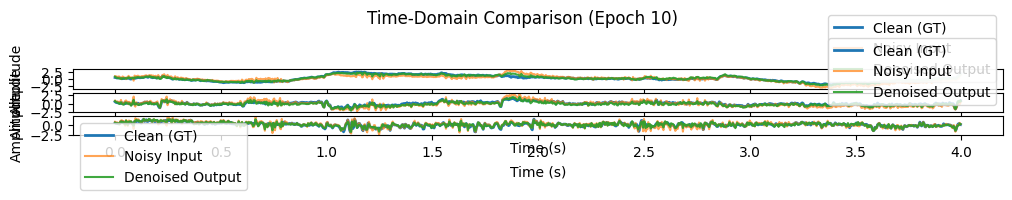

In [11]:
checkpoint_dir = "/kaggle/working"
plot_dir = os.path.join(checkpoint_dir, "epoch_plots")
os.makedirs(plot_dir, exist_ok=True)

best_loss = float("inf")
train_lossD_history = []
train_lossG_history = []
test_snr_history = []
test_rrmse_history = []
test_corr_history = []

for epoch in range(EPOCHS):
    total_lossD, total_lossG = 0.0, 0.0
    G.train()
    D.train()
    
    for artifact_input, clean_input in tqdm(train_loader, desc=f"Epoch {epoch+1}"):
        artifact_input, clean_input = artifact_input.to(device), clean_input.to(device)
        
        # --- Update Discriminator ---
        optD.zero_grad()
        real_logits = D(clean_input)
        predicted_residual = G(artifact_input)
        fake_clean = artifact_input - predicted_residual
        fake_logits = D(fake_clean.detach())
        real_labels = torch.ones_like(real_logits) * 0.9
        fake_labels = torch.zeros_like(fake_logits) + 0.1
        lossD = bce_loss(real_logits, real_labels) + bce_loss(fake_logits, fake_labels)
        lossD.backward()
        torch.nn.utils.clip_grad_norm_(D.parameters(), max_norm=1.0)
        optD.step()
        
        # --- Update Generator ---
        optG.zero_grad()
        predicted_residual = G(artifact_input)
        fake_clean = artifact_input - predicted_residual
        loss_recon = mse_loss(fake_clean, clean_input)
        loss_adv = bce_loss(D(fake_clean), real_labels)
        lossG = loss_recon + lam * loss_adv
        lossG.backward()
        torch.nn.utils.clip_grad_norm_(G.parameters(), max_norm=1.0)
        optG.step()
        
        total_lossD += lossD.item()
        total_lossG += lossG.item()
    
    avg_lossD = total_lossD / len(train_loader)
    avg_lossG = total_lossG / len(train_loader)
    train_lossD_history.append(avg_lossD)
    train_lossG_history.append(avg_lossG)
    
    print(f"Epoch {epoch+1}: D-loss = {avg_lossD:.4f}, G-loss = {avg_lossG:.4f}")
    
    # ----- Evaluate on Test Set Using Metrics & Paired t-test -----
    G.eval()
    snr_scores = []
    rrmse_scores = []
    corr_scores = []
    all_clean_signals = []
    all_denoised_signals = []
    power_threshold = 1e-6
    eps = 1e-10
    
    for artifact_input, clean_input in test_loader:
        artifact_input, clean_input = artifact_input.to(device), clean_input.to(device)
        with torch.no_grad():
            predicted_residual = G(artifact_input)
            denoised_signal = artifact_input - predicted_residual
            
        clean_np = clean_input.cpu().numpy()    # shape: [1, n_channels, SEG_LEN]
        denoised_np = denoised_signal.cpu().numpy() 
        clean_sig = clean_np[0]      # shape: [n_channels, SEG_LEN]
        denoised_sig = denoised_np[0]
        
        clean_power = np.mean(clean_sig**2)
        error_power = np.mean((clean_sig - denoised_sig)**2)
        
        if clean_power < power_threshold:
            continue
        
        all_clean_signals.append(clean_sig)
        all_denoised_signals.append(denoised_sig)
        
        snr_val = 10 * np.log10(clean_power / (error_power + eps))
        rrmse_val = np.sqrt(error_power / (clean_power + eps))
        try:
            corr_val = np.corrcoef(clean_sig.flatten(), denoised_sig.flatten())[0, 1]
        except Exception as e:
            corr_val = np.nan
        
        snr_scores.append(snr_val)
        rrmse_scores.append(rrmse_val)
        corr_scores.append(corr_val)
    
    if len(snr_scores) > 0:
        avg_snr   = np.mean(snr_scores)
        avg_rrmse = np.mean(rrmse_scores)
        avg_corr  = np.mean(corr_scores)
    else:
        avg_snr   = -np.inf
        avg_rrmse = np.inf
        avg_corr  = np.nan
    
    print(f"Epoch {epoch+1}: Avg SNR = {avg_snr:.2f} dB, Avg RRMSE = {avg_rrmse:.4f}, Avg Corr = {avg_corr:.4f}")
    
    if len(all_clean_signals) > 0:
        all_clean_flat = np.concatenate([sig.flatten() for sig in all_clean_signals])
        all_denoised_flat = np.concatenate([sig.flatten() for sig in all_denoised_signals])
        t_stat, p_val = st.ttest_rel(all_clean_flat, all_denoised_flat)
        print(f"Paired t-test: t-stat = {t_stat:.4f}, p-value = {p_val:.4e}")
    else:
        print("No valid samples for p-value computation.")
    
    test_snr_history.append(avg_snr)
    test_rrmse_history.append(avg_rrmse)
    test_corr_history.append(avg_corr)
    
    # --- Save Checkpoint ---
    checkpoint = {
        'epoch': epoch + 1,
        'G_state_dict': G.state_dict(),
        'D_state_dict': D.state_dict(),
        'optG_state_dict': optG.state_dict(),
        'optD_state_dict': optD.state_dict(),
        'lossD': avg_lossD,
        'lossG': avg_lossG,
        'snr': avg_snr
    }
    checkpoint_path = os.path.join(checkpoint_dir, f"checkpoint_epoch_{epoch+1}.pth")
    torch.save(checkpoint, checkpoint_path)
    if avg_lossG < best_loss:
        best_loss = avg_lossG
        best_checkpoint_path = os.path.join(checkpoint_dir, "checkpoint_epoch_best.pth")
        torch.save(checkpoint, best_checkpoint_path)
        print(f"✅ Best model updated (lower G-loss)! Saved at {best_checkpoint_path}")
    
    # --- Plot Time-Domain Comparison for a Test Sample ---
    for artifact_input, clean_input in test_loader:
        artifact_input, clean_input = artifact_input.to(device), clean_input.to(device)
        with torch.no_grad():
            predicted_residual = G(artifact_input)
            denoised_tensor = artifact_input - predicted_residual
        sample_artifact = artifact_input.cpu().numpy()[0]  # shape: [n_channels, SEG_LEN]
        sample_clean    = clean_input.cpu().numpy()[0]
        sample_denoised = denoised_tensor.cpu().numpy()[0]
        break
    fs = 250.0
    times = np.arange(SEG_LEN) / fs
    plt.figure(figsize=(12, 6))
    # for ch in range(n_channels):
    for ch in range(3):
        plt.subplot(n_channels, 1, ch+1)
        plt.plot(times, sample_clean[ch], label="Clean (GT)", linewidth=2)
        plt.plot(times, sample_artifact[ch], label="Noisy Input", alpha=0.7)
        plt.plot(times, sample_denoised[ch], label="Denoised Output", alpha=0.9)
        plt.xlabel("Time (s)")
        plt.ylabel("Amplitude")
        plt.legend()
    plt.suptitle(f"Time-Domain Comparison (Epoch {epoch+1})")
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.savefig(os.path.join(plot_dir, f"epoch_{epoch+1}_time.png"))
    plt.show()

# 8) Evaluation & Inference

In [12]:
# Specify the checkpoint path (modify accordingly)
best_checkpoint_path = '/kaggle/working/checkpoint_epoch_best.pth'  # or use the best epoch filename

# Load the checkpoint dictionary
checkpoint = torch.load(best_checkpoint_path, map_location=device)

# Load the model state (for inference, we only need the generator)
G.load_state_dict(checkpoint['G_state_dict'])
G.eval()  # set the generator to evaluation mode

# Initialize lists for metrics
snr_scores, rrmse_scores = [], []

# Diagnostic flag
diagnostic_done = False
eps = 1e-10            # small constant to avoid zero-denom issues
power_threshold = 1e-6 # threshold for clean signal power below which the sample is skipped

for artifact_input, clean_input in test_loader:
    artifact_input, clean_input = artifact_input.to(device), clean_input.to(device)
    
    with torch.no_grad():
        predicted_residual = G(artifact_input)
        denoised_signal = artifact_input - predicted_residual
    
    # Convert tensors to numpy arrays (assumed shape: [1, 1, SEG_LEN])
    clean_np    = clean_input.cpu().numpy()    # shape: [1, 1, SEG_LEN]
    denoised_np = denoised_signal.cpu().numpy()  # shape: [1, 1, SEG_LEN]
    
    # For convenience, pick the first sample (only one sample per batch)
    clean_sig = clean_np[0, 0]
    denoised_sig = denoised_np[0, 0]
    
    # Diagnostic: Check the first sample only (subset of 100 points)
    if not diagnostic_done:
        subset_size = 100
        clean_subset    = clean_sig[:subset_size]
        denoised_subset = denoised_sig[:subset_size]
        signal_power = np.mean(clean_subset ** 2)
        error_power  = np.mean((clean_subset - denoised_subset) ** 2)
        snr_ratio    = signal_power / (error_power + eps)
        print("===== Diagnostic for First Test Sample =====")
        print("Signal Power (mean(clean^2)):", signal_power)
        print("Error Power (mean((clean-denoised)^2)):", error_power)
        print("SNR Ratio:", snr_ratio)
        print("Computed SNR (dB):", 10 * np.log10(snr_ratio))
        print("=============================================")
        diagnostic_done = True

    # Compute overall power of the clean signal over the full segment
    clean_power = np.mean(clean_sig ** 2)
    
    # If the clean signal energy is extremely low, skip this sample.
    if clean_power < power_threshold:
        continue

    error_power = np.mean((clean_sig - denoised_sig) ** 2)
    
    # Compute metrics:
    snr_val = 10 * np.log10(clean_power / (error_power + eps))
    rrmse_val = np.sqrt(error_power / (clean_power + eps))
    
    snr_scores.append(snr_val)
    rrmse_scores.append(rrmse_val)

# Compute aggregated statistics if we have valid samples.
n_samples = len(snr_scores)
if n_samples == 0:
    print("No valid samples for evaluation (clean signal power is too low).")
else:
    avg_snr   = np.mean(snr_scores)
    std_snr   = np.std(snr_scores)
    avg_rrmse = np.mean(rrmse_scores)
    std_rrmse = np.std(rrmse_scores)
    
    # Compute 95% confidence intervals using t-distribution:
    ci_snr   = st.t.interval(0.95, n_samples - 1, loc=avg_snr, scale=(std_snr/np.sqrt(n_samples)))
    ci_rrmse = st.t.interval(0.95, n_samples - 1, loc=avg_rrmse, scale=(std_rrmse/np.sqrt(n_samples)))
    
    # Final aggregated metrics:
    print(f"✅ Final Evaluation Metrics:")
    print(f"Avg SNR: {avg_snr:.2f} dB, Std: {std_snr:.2f}, 95% CI: {ci_snr}")
    print(f"Avg RRMSE: {avg_rrmse:.4f}, Std: {std_rrmse:.4f}, 95% CI: {ci_rrmse}")


/tmp/ipykernel_31/544094359.py:5: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(best_checkpoint_path, map_location=device)


===== Diagnostic for First Test Sample =====
Signal Power (mean(clean^2)): 0.15692171
Error Power (mean((clean-denoised)^2)): 0.023651963
SNR Ratio: 6.63461689071864
Computed SNR (dB): 8.218158500262936
✅ Final Evaluation Metrics:
Avg SNR: 13.55 dB, Std: 6.22, 95% CI: (13.370641778690501, 13.730904525911782)
Avg RRMSE: 0.3600, Std: 1.2984, 95% CI: (0.3224344844431124, 0.3975846812438487)


# 8) Plot learning curves

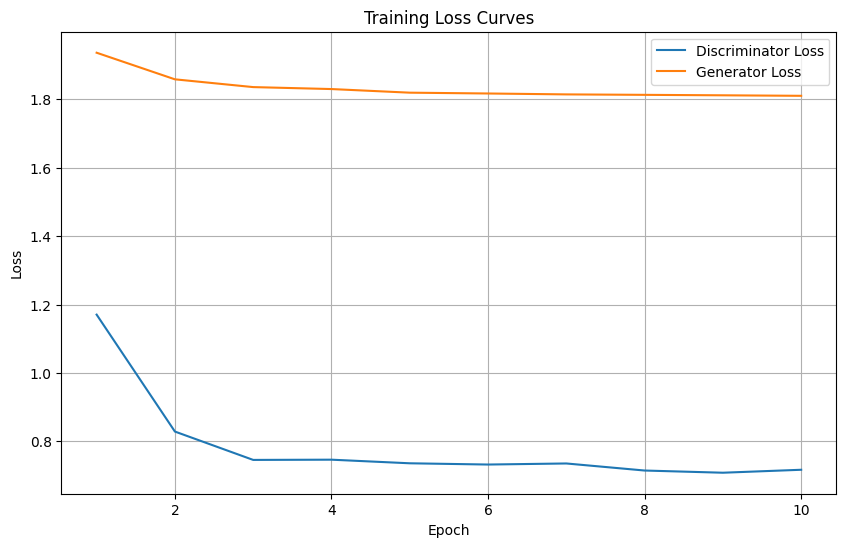

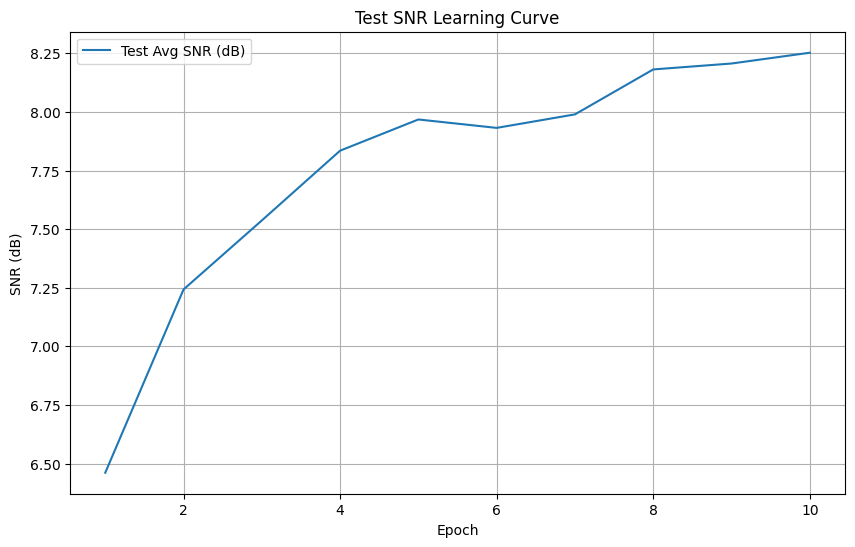

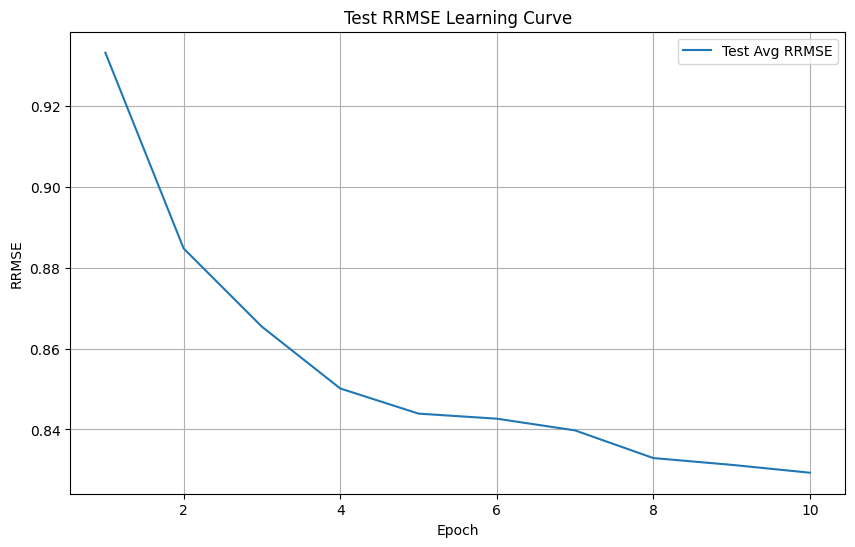

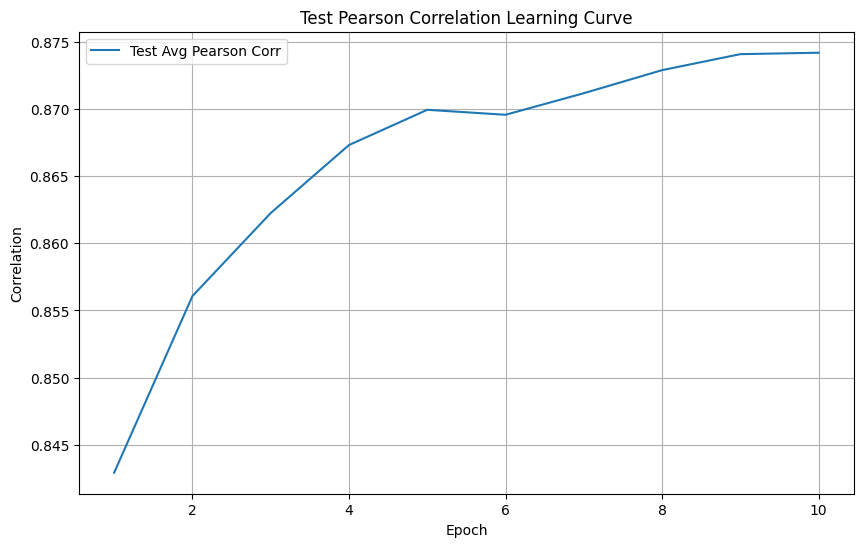

In [13]:
epochs_arr = np.arange(1, EPOCHS+1)

plt.figure(figsize=(10,6))
plt.plot(epochs_arr, train_lossD_history, label="Discriminator Loss")
plt.plot(epochs_arr, train_lossG_history, label="Generator Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss Curves")
plt.legend()
plt.grid(True)
plt.savefig(os.path.join(checkpoint_dir, "training_loss_curves.png"))
plt.show()

plt.figure(figsize=(10,6))
plt.plot(epochs_arr, test_snr_history, label="Test Avg SNR (dB)")
plt.xlabel("Epoch")
plt.ylabel("SNR (dB)")
plt.title("Test SNR Learning Curve")
plt.legend()
plt.grid(True)
plt.savefig(os.path.join(checkpoint_dir, "test_snr_learning_curve.png"))
plt.show()

plt.figure(figsize=(10,6))
plt.plot(epochs_arr, test_rrmse_history, label="Test Avg RRMSE")
plt.xlabel("Epoch")
plt.ylabel("RRMSE")
plt.title("Test RRMSE Learning Curve")
plt.legend()
plt.grid(True)
plt.savefig(os.path.join(checkpoint_dir, "test_rrmse_learning_curve.png"))
plt.show()

plt.figure(figsize=(10,6))
plt.plot(epochs_arr, test_corr_history, label="Test Avg Pearson Corr")
plt.xlabel("Epoch")
plt.ylabel("Correlation")
plt.title("Test Pearson Correlation Learning Curve")
plt.legend()
plt.grid(True)
plt.savefig(os.path.join(checkpoint_dir, "test_corr_learning_curve.png"))
plt.show()